In [175]:
import pandas as pd
import numpy as np
import os
from datetime import datetime
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import seaborn as sns

load_dotenv()

print(os.getenv("COMTRADE_API_KEY"))

d4457e079e6240cc8f74def00b4e192f


In [176]:
nat_gas_codes = {271111: 'Natural gas, liquefied',
                 271121: 'Natural gas, gaseous'}

year_list = list(range(2000, datetime.now().year)) # list of all years from 2000 to now

folder_name = 'nat_gas_2000-2025_Trade_data'


In [177]:
dfr = pd.read_parquet(os.path.join(folder_name, 'nat_gas_trade_df'), engine='pyarrow') #df for dollar analysis

dfr_kg = pd.read_parquet(os.path.join(folder_name, 'nat_gas_trade_df_kg'), engine='pyarrow') #df for kg analysis
dfr.shape, dfr_kg.shape

((91526, 28), (83492, 29))

WARNING: DATA FOR 2025 CAN BE NOT FULL YET!!!

In [178]:
dfs_list = [dfr, dfr_kg]
dfs_cols = {'primaryValue': dfr, 'netWgt': dfr_kg}

print('Grouping trade in dollars and kilograms by transport for each type of gas: \n')
for col, df in dfs_cols.items():
    print(df.groupby(['transport', 'type'])[col].agg('sum').head(8))

Grouping trade in dollars and kilograms by transport for each type of gas: 

transport                 type     
Air                       gaseous      4.147494e+09
                          liquefied    2.027763e+10
Inland waterway           gaseous      1.310085e+08
                          liquefied    6.221765e+07
Land                      gaseous      1.378928e+10
                          liquefied    7.557314e+08
Not elsewhere classified  gaseous      9.785937e+09
                          liquefied    2.917186e+10
Name: primaryValue, dtype: float64
transport                 type     
Air                       gaseous      8.658603e+09
                          liquefied    3.436293e+10
Inland waterway           gaseous      2.361933e+08
                          liquefied    9.269630e+07
Land                      gaseous      3.978005e+10
                          liquefied    3.602702e+08
Not elsewhere classified  gaseous      1.706412e+10
                          liquefied 

In [179]:
def to_billions(df, col):
    """
    Function that divides all values in a given column on 10**9 to represent values in billions
    """
    return df[col] / 10**9
gas_types = list(dfr.type.unique())
gas_types

['gaseous', 'liquefied']

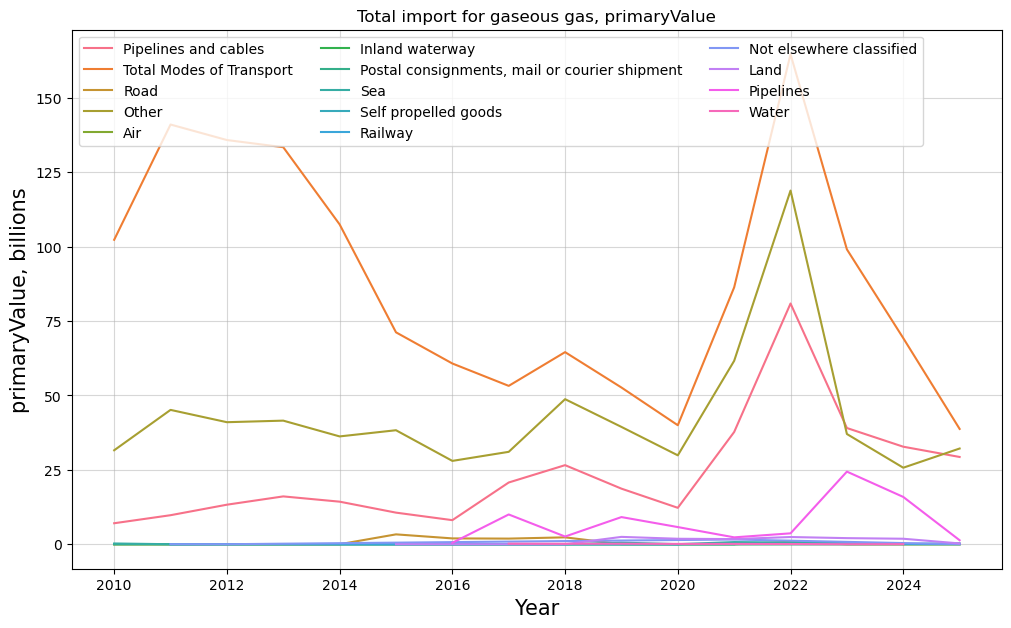

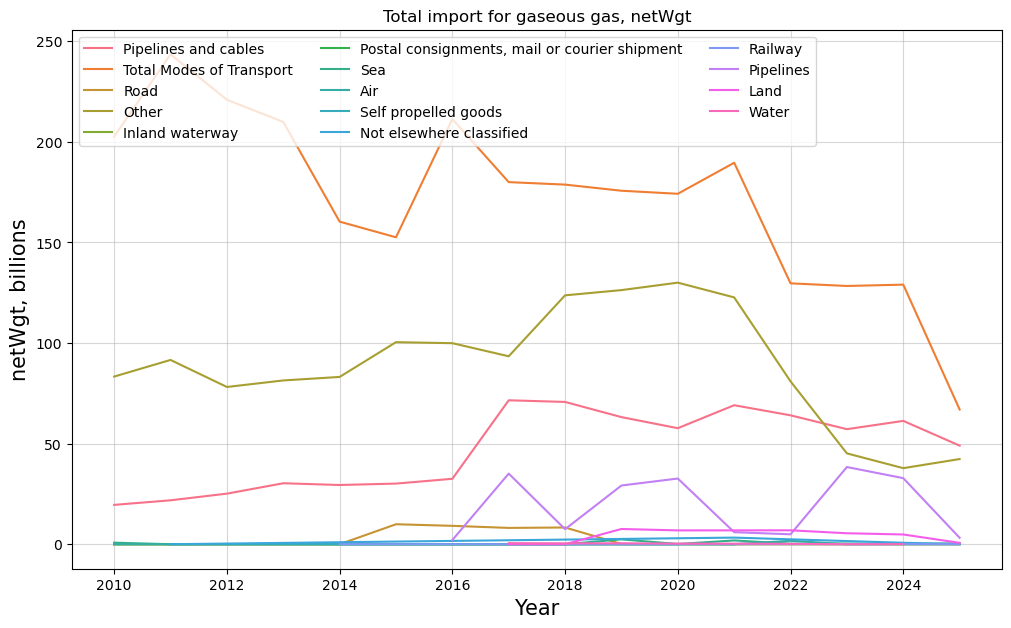

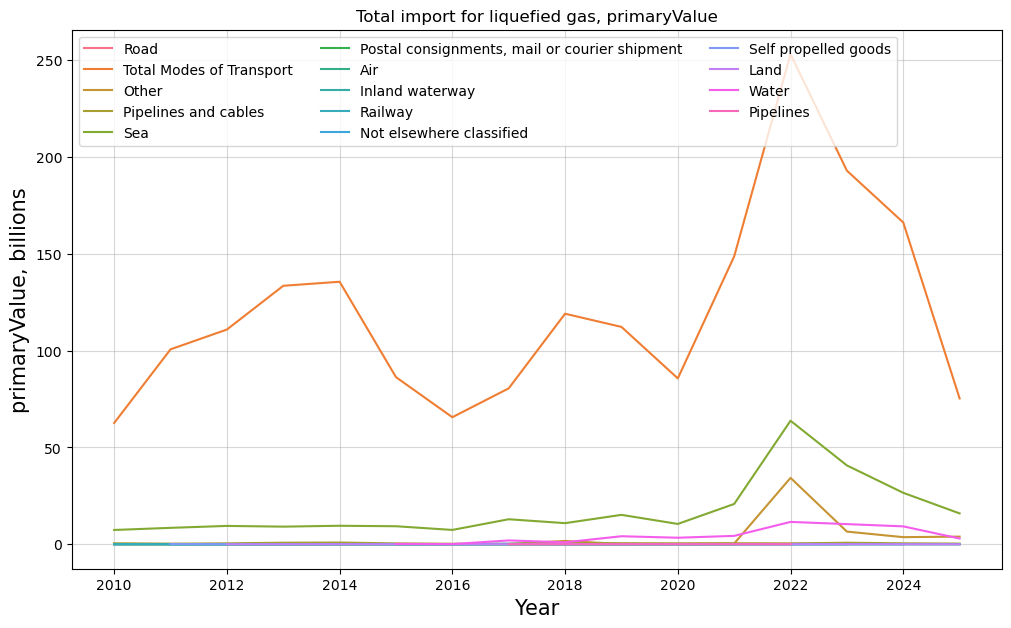

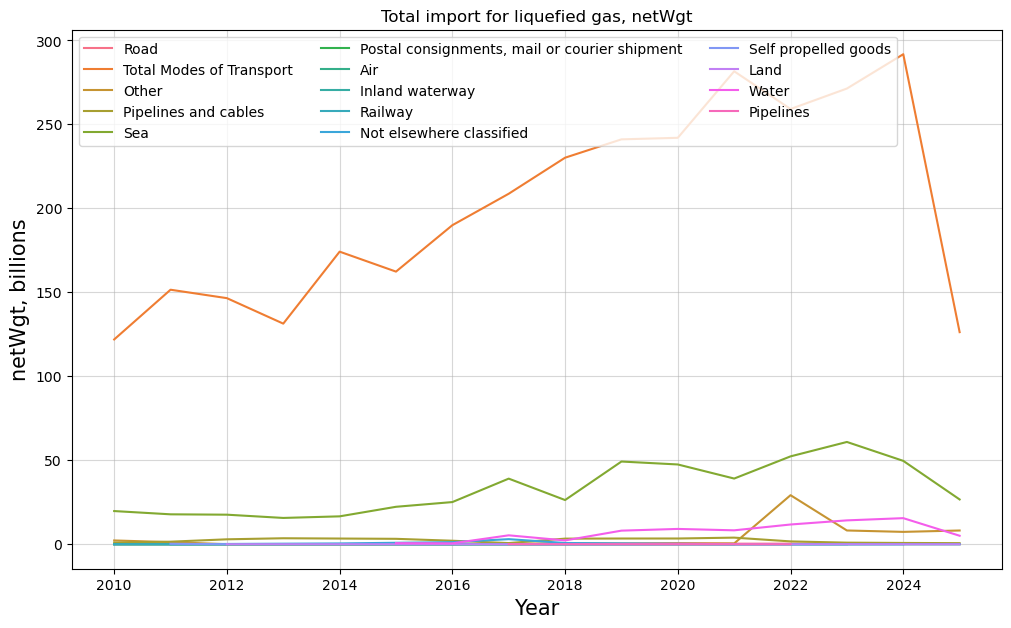

In [180]:
for gas in gas_types:
    for col, df in dfs_cols.items(): #I represent import because it is more reliable than export because better reported (for tariffs calculations)
        plt.figure(figsize=(12,7))
        sns.lineplot(data=df[(df.flow == 'Import') & (df.type == gas)], 
                     y=to_billions(df, col), x = 'refYear', hue='transport', errorbar=None,estimator='sum') # to plot sums, not means by default
        plt.ylabel(str(col) + ', billions',size=15)
        plt.xlabel('Year', size=15)
        plt.legend(ncol=3, loc='upper left')
        plt.title('Total import for ' + str(gas) + ' gas, ' + str(col))
        plt.grid(alpha=0.5)

In [183]:
#top trade routes of import for dollar values

dfr[ (dfr.refYear > 2020) & (dfr.flow == 'Import') & ~ ((dfr.transport == 'Total Modes of Transport') | (dfr.transport == 'Other'))
    ].groupby(['refYear', 'type', 'transport'])['primaryValue'].agg('sum').groupby(['refYear', 'type']).nlargest(2).droplevel([0,1])

refYear  type       transport           
2021     gaseous    Pipelines and cables    3.770780e+10
                    Pipelines               2.308424e+09
         liquefied  Sea                     2.079835e+10
                    Water                   4.308385e+09
2022     gaseous    Pipelines and cables    8.087383e+10
                    Pipelines               3.654780e+09
         liquefied  Sea                     6.379188e+10
                    Water                   1.152821e+10
2023     gaseous    Pipelines and cables    3.903901e+10
                    Pipelines               2.439496e+10
         liquefied  Sea                     4.070491e+10
                    Water                   1.039059e+10
2024     gaseous    Pipelines and cables    3.276140e+10
                    Pipelines               1.588542e+10
         liquefied  Sea                     2.655297e+10
                    Water                   9.216863e+09
2025     gaseous    Pipelines and cables    2.9

In [184]:
#top trade routes of import for kg values

top_transport = dfr_kg[ (dfr_kg.refYear > 2020) & (dfr_kg.flow == 'Import') & ~ ((dfr_kg.transport == 'Total Modes of Transport')
| (dfr_kg.transport == 'Other'))].groupby(['refYear', 'type', 'transport'])['netWgt'].agg('sum')

top_transport = top_transport.groupby(['refYear', 'type']).nlargest(2)
top_transport.droplevel([0,1]).reset_index()

,refYear,type,transport,netWgt
0,2021,gaseous,Pipelines and cables,6.908370e+10
1,2021,gaseous,Land,6.887258e+09
2,2021,liquefied,Sea,3.910382e+10
3,2021,liquefied,Water,8.276041e+09
4,2022,gaseous,Pipelines and cables,6.405887e+10
5,2022,gaseous,Land,6.913792e+09
6,2022,liquefied,Sea,5.231123e+10
7,2022,liquefied,Water,1.174397e+10
8,2023,gaseous,Pipelines and cables,5.717703e+10
9,2023,gaseous,Pipelines,3.835906e+10


Now let us will define top routes by how often did they occur as top routes in each year.
I will also do by sum of all years, but too huge differences in (e.g. in 2022) can artifically give some routes bigger value (it will be just scaled by high prices). In kg df numbers can be altered since it was filtered.

Further you can see a still showed top routes by total trade: they are almost similar to top routes by historical occurrences 
but they differ a bit between kg and dollar values. In contrast, occurences are consistent for both dollars and kg.

So present all top-7 routes by each type fo analysis.

In [185]:
doll_df = dfr.groupby(['type', 'transport']).primaryValue.agg('sum')
doll_df = doll_df.groupby('type').nlargest(7).droplevel(0).reset_index()
doll_df #top routes by total trade in dollars

,type,transport,primaryValue
0,gaseous,Total Modes of Transport,2.628862e+12
1,gaseous,Other,9.238449e+11
2,gaseous,Pipelines and cables,4.416054e+11
3,gaseous,Pipelines,2.211250e+11
4,gaseous,Road,2.696244e+10
5,gaseous,Land,1.378928e+10
6,gaseous,Not elsewhere classified,9.785937e+09
7,liquefied,Total Modes of Transport,2.648358e+12
8,liquefied,Sea,3.869273e+11
9,liquefied,Other,2.591283e+11


In [186]:
kg_df = dfr_kg.groupby(['type', 'transport']).netWgt.agg('sum').groupby('type').nlargest(7).droplevel(0).reset_index()
kg_df #top routes by total trade in kg

,type,transport,netWgt
0,gaseous,Total Modes of Transport,4.922014e+12
1,gaseous,Other,2.022925e+12
2,gaseous,Pipelines and cables,8.373574e+11
3,gaseous,Pipelines,5.472185e+11
4,gaseous,Road,8.012689e+10
5,gaseous,Land,3.978005e+10
6,gaseous,Not elsewhere classified,1.706412e+10
7,liquefied,Total Modes of Transport,4.430764e+12
8,liquefied,Sea,7.539747e+11
9,liquefied,Other,4.172606e+11


In [187]:
top_routes = dfr.groupby(['refYear', 'type', 'transport'])['primaryValue'].agg('sum').groupby(['refYear', 'type']).nlargest(7)

top_routes = top_routes.droplevel([0,1]).reset_index()
top_routes = top_routes.groupby('type').transport.value_counts().groupby('type').nlargest(7).droplevel(0).reset_index()

top_routes # top routes by occurences (for kg df occurrences give the same result)

,type,transport,count
0,gaseous,Other,16
1,gaseous,Pipelines,16
2,gaseous,Pipelines and cables,16
3,gaseous,Total Modes of Transport,16
4,gaseous,Road,14
5,gaseous,Land,9
6,gaseous,Sea,9
7,liquefied,Road,16
8,liquefied,Sea,16
9,liquefied,Total Modes of Transport,16


In [188]:
routes = {'gaseous': list(top_routes[top_routes.type == 'gaseous'].transport.unique()),
          'liquefied': list(top_routes[top_routes.type == 'liquefied'].transport.unique())}
print('Top routes by historical occurrences: \n', routes)

Top routes by historical occurrences: 
 {'gaseous': ['Other', 'Pipelines', 'Pipelines and cables', 'Total Modes of Transport', 'Road', 'Land', 'Sea'], 'liquefied': ['Road', 'Sea', 'Total Modes of Transport', 'Other', 'Pipelines and cables', 'Water', 'Pipelines']}


In [189]:
print('We see that most of the largest trades are either "Total Modes of Transport" or "Other"')
dfr.loc[dfr.primaryValue.nlargest(1000).index, :].transport.value_counts()

We see that most of the largest trades are either "Total Modes of Transport" or "Other"


transport
Total Modes of Transport    616
Other                       303
Pipelines and cables         37
Pipelines                    22
Sea                          13
Not elsewhere classified      9
Name: count, dtype: int64

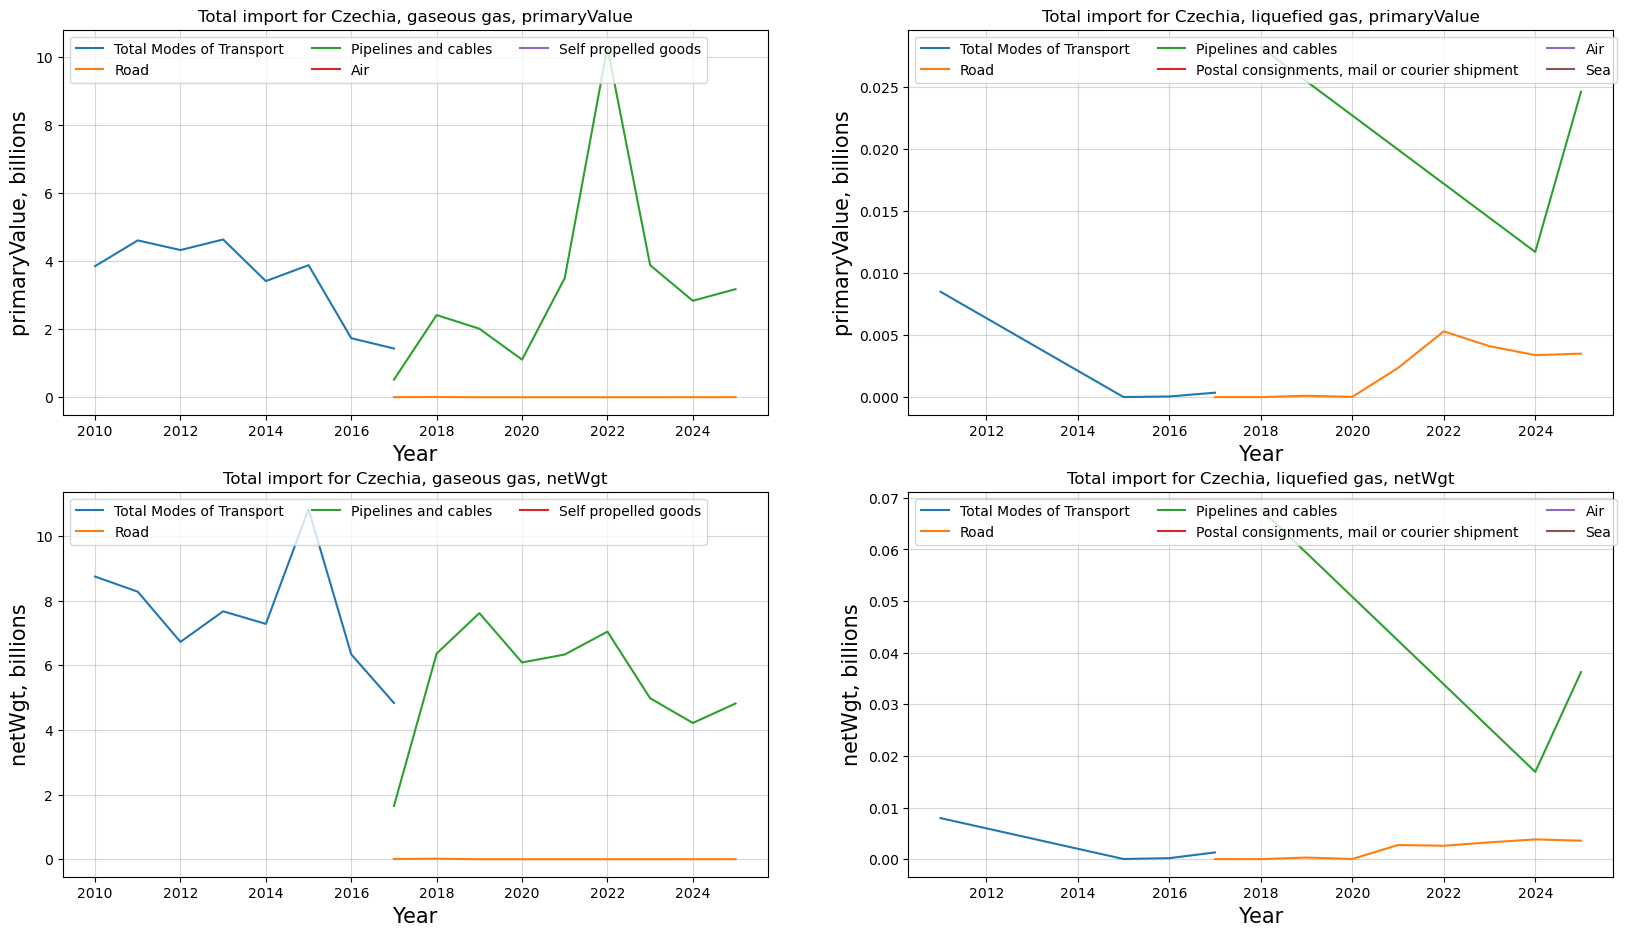

In [190]:
def country_plot(country):
    if country in dfr_kg.reporter.unique():
        plt.figure(figsize=(20,11))
        for i, gas in enumerate(gas_types):
            for col, df in dfs_cols.items():
                plt.subplot(2, 2, i + list((dfs_cols.keys())).index(col)*2 + 1) #to make 4 indexes for each subplot - a bit of math
                sns.lineplot(data=df[(df.reporter == country) & (df.type == gas)], 
                                    y=to_billions(df, col), x = 'refYear', hue='transport', errorbar=None,estimator='sum') # to plot sums, not means by default
                plt.ylabel(str(col) + ', billions',size=15)
                plt.xlabel('Year', size=15)
                plt.legend(ncol=3, loc='upper left')
                plt.title('Total import for ' +country + ', '+ str(gas) + ' gas, ' + str(col) )
                plt.grid(alpha=0.5)
    else:
        print('This is a not a valid name of country in the Harmonised System. Please, type a valid name.')


country_plot('Czechia')

As expected, countries report modes of transport relatively chaotically: especially, the largest countries label almost everything as "Total Modes of Transport". This makes transport and country-wise analysis difficult since space for analysis is not very large.
Further analysis focuses on global trends.

In [191]:
prices = dfr_kg.groupby(['type','flow', 'transport'])[['primaryValue', 'netWgt']].agg('sum').reset_index()
prices['price'] = prices.primaryValue / prices.netWgt
prices = prices[(prices.netWgt > 10**6) & (prices.transport != 'Postal consignments, mail or courier shipment')] #no economic logic, too small values
prices.head()

,type,flow,transport,primaryValue,netWgt,price
0,gaseous,Export,Air,3.256615e+09,6.746106e+09,0.482740
1,gaseous,Export,Inland waterway,1.218786e+08,2.124933e+08,0.573564
2,gaseous,Export,Land,8.201542e+08,5.708508e+08,1.436723
3,gaseous,Export,Not elsewhere classified,7.758477e+09,1.298284e+10,0.597595
4,gaseous,Export,Other,2.312235e+11,6.027315e+11,0.383626


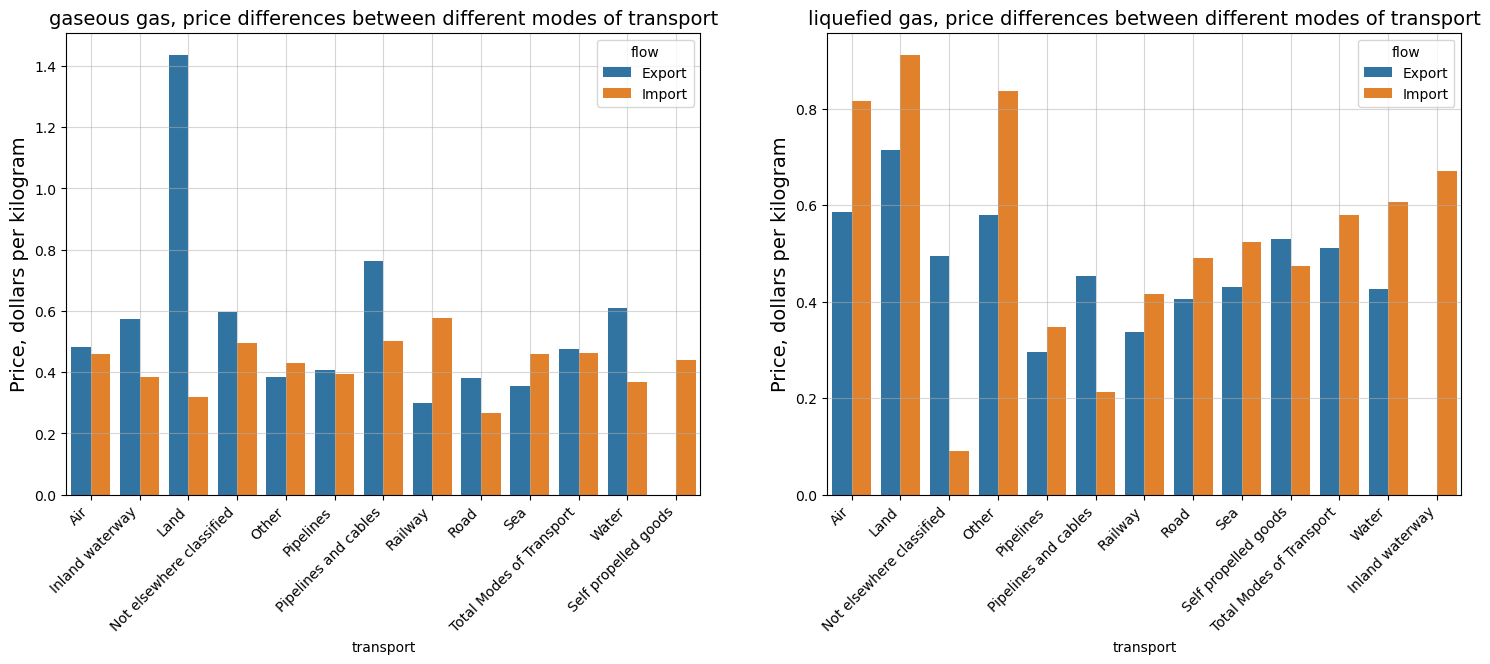

In [192]:
plt.figure(figsize=(18, 6))
for i, gas in enumerate(gas_types):
    plt.subplot(1, 2, i+1)
    sns.barplot(data=prices[prices.type==gas], x='transport', y = 'price', errorbar=None, hue='flow')
    plt.ylabel('Price, dollars per kilogram', size=14)
    plt.title(str(gas) + ' gas, price differences between different modes of transport', size=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(alpha=0.5)  #now graphs are not adjusted to one scale - I will compare them in the later analysis

In [ ]:
dfr_kg[(dfr_kg.type == 'gaseous') & (dfr_kg.transport == 'Land') & (dfr_kg.flow == 'Export')].sample(5)

In [ ]:
dfr_kg[(dfr_kg.type == 'liquefied') & (dfr_kg.transport == 'Not elsewhere classified') 
       & (dfr_kg.flow == 'Import') & (dfr_kg.reporter == 'South Africa')].sample(5)

Discussion:
We see that prices for gaseous and liquefied types of gas per kg are in one range, but liquefied is more expensive. The gaseous type has one outlier - the high price of export through land. There are 183 rows with moderate export trades through land - they can be results of some emergent needs, and the land route is not the most efficient for gas, which is why the prices are higher than average. 
Liquified gas has too low prices for 'Not elsewhere classified' type, 55 rows. It happened because South Africa imported from Mozambique at very low prices - possibly, the product of some negotiations or counterfeit. 

Price differences between export and import are the premiums taken by merchants and dealers who trade gas internationally. 

In [193]:
prices.head()

,type,flow,transport,primaryValue,netWgt,price
0,gaseous,Export,Air,3.256615e+09,6.746106e+09,0.482740
1,gaseous,Export,Inland waterway,1.218786e+08,2.124933e+08,0.573564
2,gaseous,Export,Land,8.201542e+08,5.708508e+08,1.436723
3,gaseous,Export,Not elsewhere classified,7.758477e+09,1.298284e+10,0.597595
4,gaseous,Export,Other,2.312235e+11,6.027315e+11,0.383626


In [194]:
saldo = prices.pivot(index = ['type', 'transport'],columns='flow', values='price') #pivoting flow to have 2 columns to easily substract
saldo['diff'] = saldo.Export - saldo.Import
saldo.reset_index(inplace=True)
saldo.head()

flow,type,transport,Export,Import,diff
0,gaseous,Air,0.482740,0.457820,0.024920
1,gaseous,Inland waterway,0.573564,0.385231,0.188333
2,gaseous,Land,1.436723,0.320130,1.116593
3,gaseous,Not elsewhere classified,0.597595,0.496769,0.100826
4,gaseous,Other,0.383626,0.429046,-0.045420


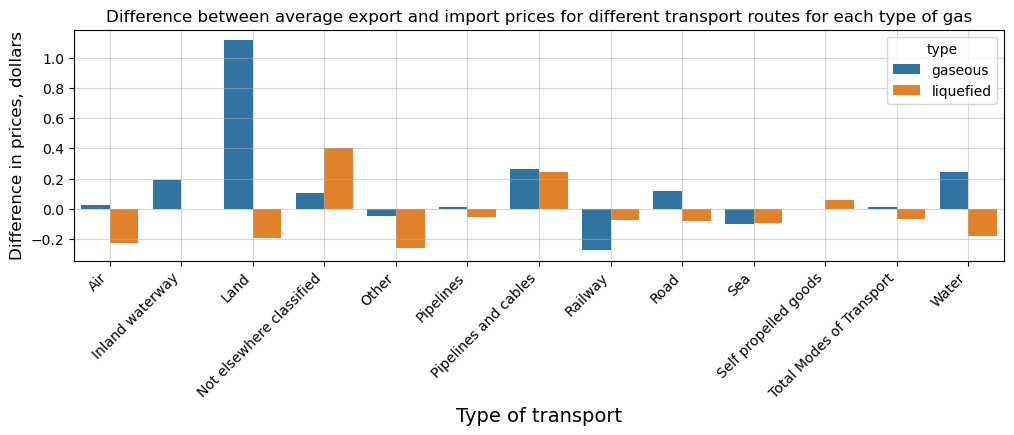

In [197]:
plt.figure(figsize=(12, 3))
sns.barplot(data=saldo, x='transport', y = 'diff', errorbar=None, hue='type')
plt.ylabel('Difference in prices, dollars', size=12)
plt.xlabel('Type of transport', size=14)
plt.title('Difference between average export and import prices for different transport routes for each type of gas', size=12)
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.5)

In [198]:
price_evol = dfr_kg.groupby(['type','refYear'])[['primaryValue', 'netWgt']].sum().reset_index()
price_evol['price'] = price_evol.primaryValue / price_evol.netWgt
price_evol.head()

,type,refYear,primaryValue,netWgt,price
0,gaseous,2010,1.648484e+11,4.805362e+11,0.343051
1,gaseous,2011,2.457164e+11,5.182220e+11,0.474153
2,gaseous,2012,2.492005e+11,4.862061e+11,0.512541
3,gaseous,2013,2.485084e+11,4.740192e+11,0.524258
4,gaseous,2014,1.885922e+11,4.354559e+11,0.433091


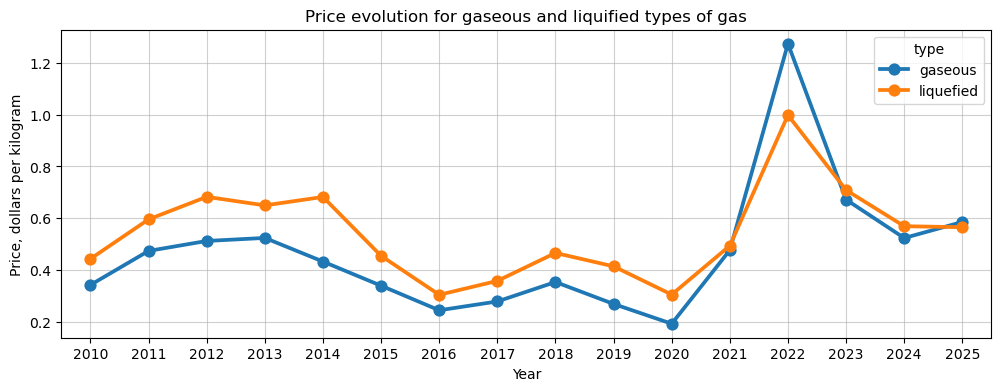

In [200]:
plt.figure(figsize=(12,4))
sns.pointplot(data=price_evol, x='refYear', y='price', hue='type')
plt.title('Price evolution for gaseous and liquified types of gas')
plt.ylabel('Price, dollars per kilogram')
plt.xlabel('Year')
plt.grid(alpha=0.6)

Primarily, liquefied gas is more expensive per kilogram than gaseous because of the costs of liquefaction and shipping.
An interesting situation happened in 2022: the gaseous type became more expensive for a period of time. The resulting value for the year is smoothed; the peak difference was much larger. That happened because of the global energy crisis, which started in 2021 (https://en.wikipedia.org/wiki/Global_energy_crisis_(2021%E2%80%932023)) and the Russian invasion of Ukraine, which started in 2022.
Currently, the situation seems to have stabilised with still higher prices than the median.

In [201]:
route_prices = dfr_kg.groupby(['type','refYear', 'transport'])[['primaryValue', 'netWgt']].agg('sum').reset_index()
route_prices['price'] = route_prices.primaryValue / route_prices.netWgt
print(route_prices.shape)
route_prices = route_prices[(route_prices.netWgt > 10**8)] #to represent only the most reliable values and avoid overlapping
route_prices.shape

(330, 6)


(203, 6)

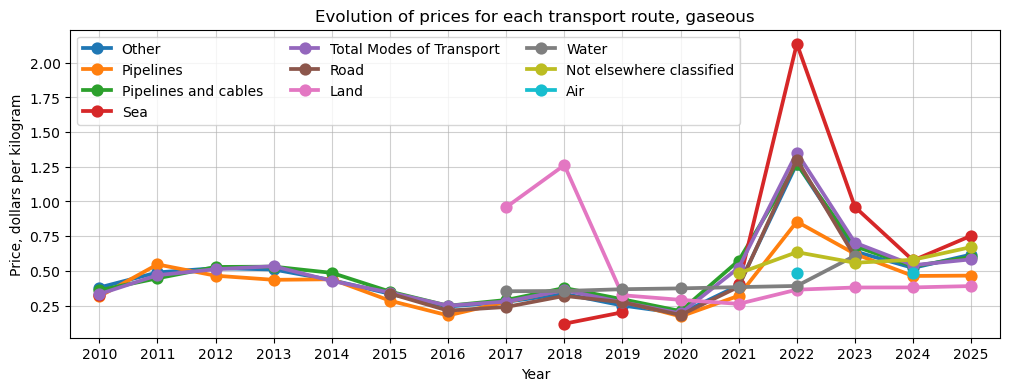

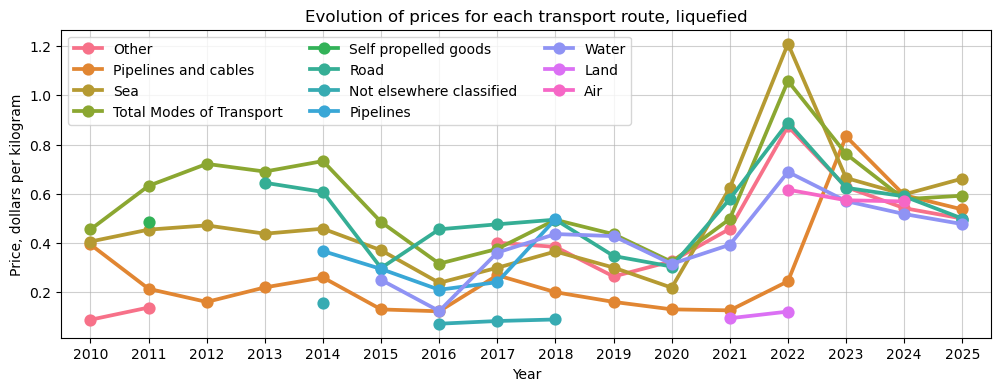

In [202]:
for gas_type in gas_types:
    plt.figure(figsize=(12,4))
    sns.pointplot(data=route_prices[route_prices.type==gas_type], x='refYear', y='price', hue='transport')
    plt.title('Evolution of prices for each transport route, ' +str(gas_type))
    plt.ylabel('Price, dollars per kilogram')
    plt.xlabel('Year')
    plt.legend(ncol=3)
    plt.grid(alpha=0.6)

Summarising results:
This analysis was devoted to transport routes and price differences. More insights will be understandable with other parts of the analysis; however, some things can be stressed at this point:

1. Most of the trades are classified as "Total Modes of Transport" or "Other" - major countries do not want to give information about their trade of such a strategic resource as natural gas. For the gaseous type, the top route is Pipelines. Other important routes are (unexpectedly) Road and Land with Sea. Liquefied type is primarily traded by Sea and Water (which is the same); other major transport modes are Pipelines and (again, unexpectedly) even Air.

2. Pipelines (and cables), railway, road, and water/sea from all defined (not "total" or "other") modes show the lowest average prices across history for both types of gas (except for "Pipelines and Cables" for gaseous). Land and air are usually the most expensive routes - usually traded not regularly, in moderate amounts, which can tell about the emergence of these trades. 

3. Prices of liquefied gas are higher; however, the crisis in 2022 is vividly visible - the gaseous type became scarce, and Sea trade prices skyrocketed. Historically, price range between different routes was smaller for gaseous type than for liquefied, where sea transport was twice as expensive as pipelines; however, in 2022 range of prices for different transport modes widened frighteningly. For now, the situation seems to have stabilised. The 2022 crisis needs attention in subsequent analysis.